<a href="https://colab.research.google.com/github/biswal-prem-5677/Coding-Journey/blob/main/python/projects/iris_dataset.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
print(5)

5


In [ ]:
import pandas as pd
import numpy as np
data = pd.read_csv('/content/iris.csv')
data.head()

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


In [ ]:
import numpy as np

# Load the Iris dataset (CSV format)
#Replace 'path/to/iris.csv' with your actual CSV file path
data = np.genfromtxt('/content/iris.csv', delimiter=',', dtype=str, skip_header=1)

# Convert numeric part to float
features = data[:, :-1].astype(float)
labels = data[:, -1]

# Separate features and labels
print("Features shape:", features.shape)
print("Labels shape:", labels.shape)

# Compute basic statistics
mean = np.mean(features, axis=0)
min_val = np.min(features, axis=0)
max_val = np.max(features, axis=0)
std = np.std(features, axis=0)

print("\n Basic Statistics:")
print("Mean: ", mean)
print("Min: ", min_val)
print("Max: ", max_val)
print("Std Dev: ", std)

# Slice the dataset by species
species_names = np.unique(labels)
species_dict = {species: features[labels == species] for species in species_names}

# Compare petal and sepal lengths
print("\n Petal and Sepal Length Comparison (mean):")
for species in species_names:
    data = species_dict[species]
    print(f"{species}: Sepal Length = {np.mean(data[:, 0]):.2f}, Petal Length = {np.mean(data[:, 2]):.2f}")

# Find the species with the longest average petal length
avg_petal_lengths = {species: np.mean(data[:, 2]) for species, data in species_dict.items()}
longest_species = max(avg_petal_lengths, key=avg_petal_lengths.get)

print(f"\n Species with longest average petal length: {longest_species} ({avg_petal_lengths[longest_species]:.2f})")


Features shape: (150, 4)
Labels shape: (150,)

 Basic Statistics:
Mean:  [5.84333333 3.054      3.75866667 1.19866667]
Min:  [4.3 2.  1.  0.1]
Max:  [7.9 4.4 6.9 2.5]
Std Dev:  [0.82530129 0.43214658 1.75852918 0.76061262]

 Petal and Sepal Length Comparison (mean):
setosa: Sepal Length = 5.01, Petal Length = 1.46
versicolor: Sepal Length = 5.94, Petal Length = 4.26
virginica: Sepal Length = 6.59, Petal Length = 5.55

 Species with longest average petal length: virginica (5.55)


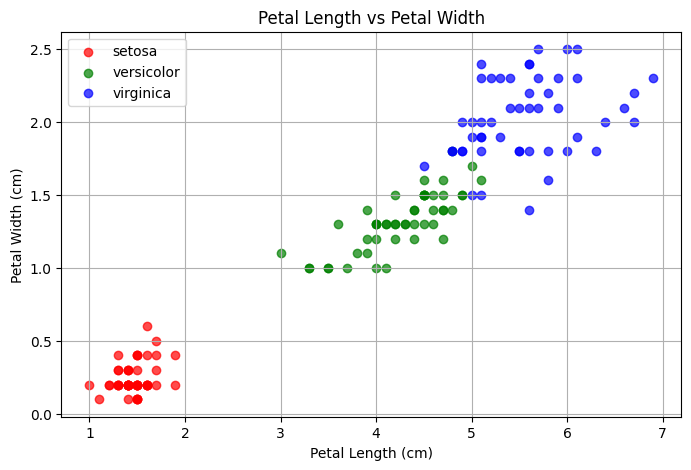

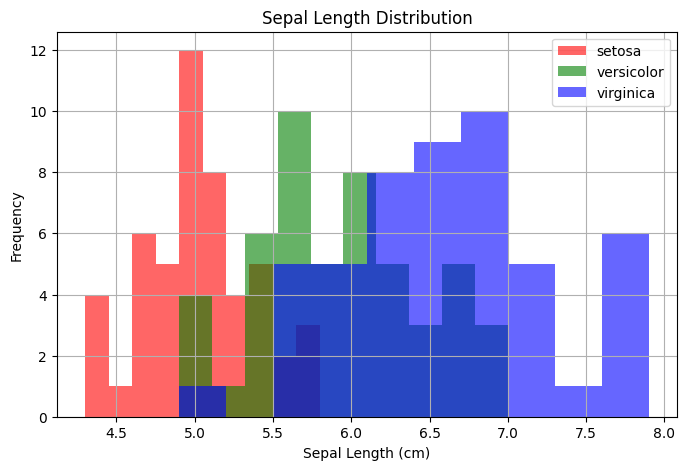

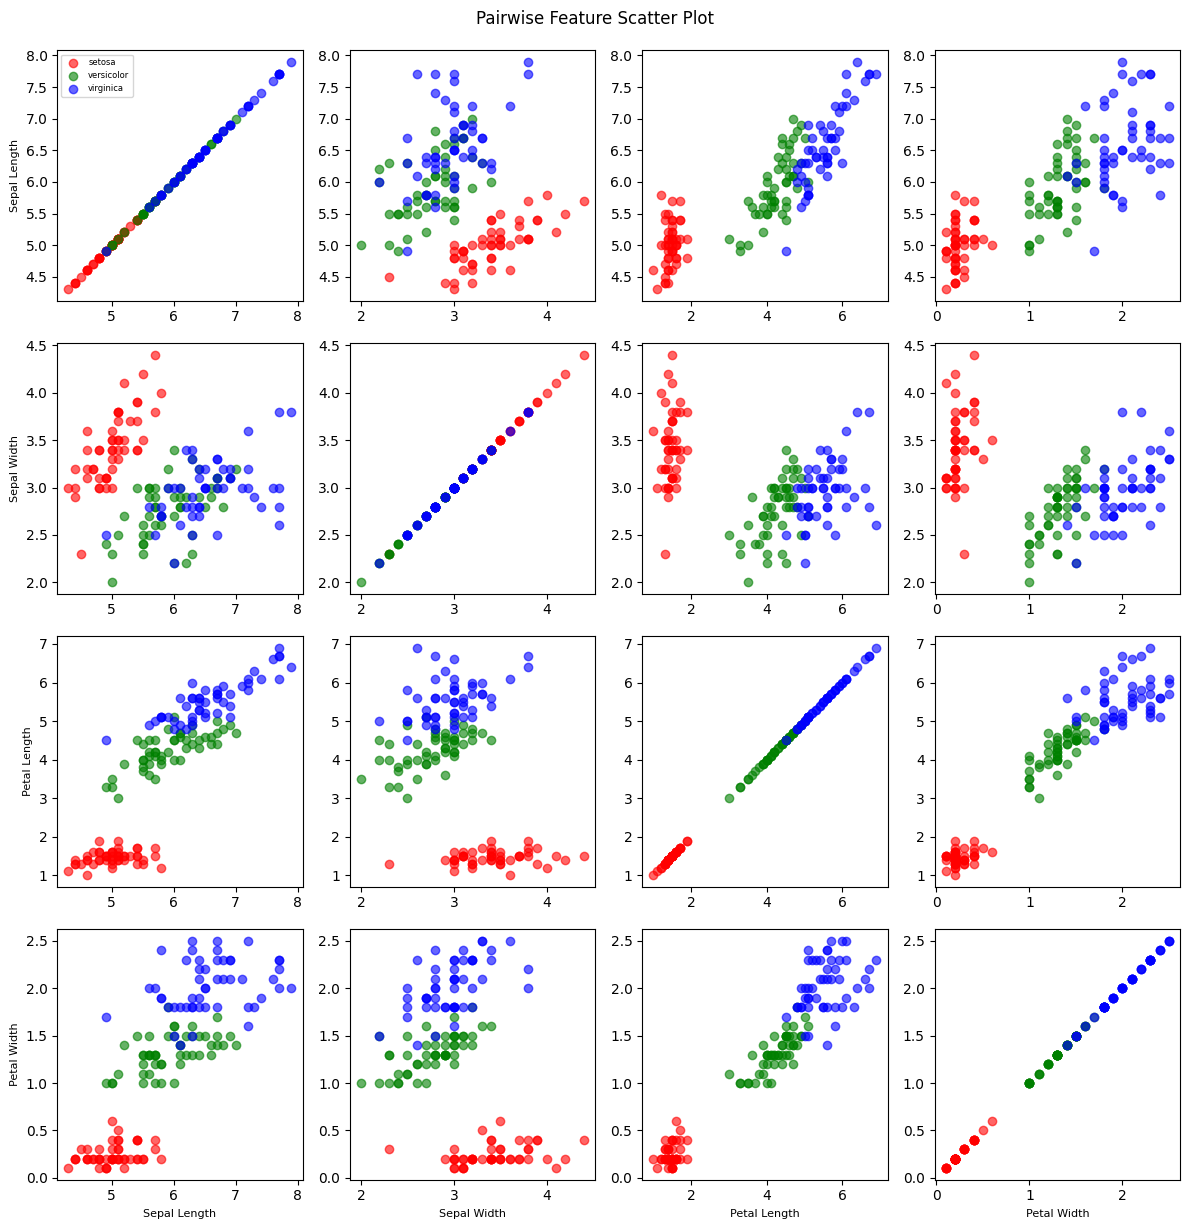

In [ ]:
import matplotlib.pyplot as plt

# Assign colors for each species
color_map = {np.str_('setosa'): 'red', np.str_('versicolor'): 'green', np.str_('virginica'): 'blue'}

# Scatter Plot: Petal Length vs Petal Width
plt.figure(figsize=(8, 5))
for species in species_names:
    species_data = species_dict[species]
    plt.scatter(species_data[:, 2], species_data[:, 3],
                label=species, color=color_map[species], alpha=0.7)
plt.title("Petal Length vs Petal Width")
plt.xlabel("Petal Length (cm)")
plt.ylabel("Petal Width (cm)")
plt.legend()
plt.grid(True)
plt.show()

# Histogram: Sepal Length Distribution per Species
plt.figure(figsize=(8, 5))
for species in species_names:
    species_data = species_dict[species]
    plt.hist(species_data[:, 0], bins=10, alpha=0.6, label=species, color=color_map[species])
plt.title("Sepal Length Distribution")
plt.xlabel("Sepal Length (cm)")
plt.ylabel("Frequency")
plt.legend()
plt.grid(True)
plt.show()

# Pairwise Scatter Plot of Features
feature_names = ["Sepal Length", "Sepal Width", "Petal Length", "Petal Width"]
plt.figure(figsize=(12, 12))
for i in range(4):
    for j in range(4):
        plt.subplot(4, 4, i*4 + j + 1)
        for species in species_names:
            data = species_dict[species]
            plt.scatter(data[:, j], data[:, i],
                        color=color_map[species], label=species, alpha=0.6)
        if i == 3:
            plt.xlabel(feature_names[j], fontsize=8)
        if j == 0:
            plt.ylabel(feature_names[i], fontsize=8)
        if i == 0 and j == 0:
            plt.legend(fontsize=6)
plt.tight_layout()
plt.suptitle("Pairwise Feature Scatter Plot", y=1.02)
plt.show()